# COGS 181 — DeepCNN Re-Run: `lr=0.01`

**Purpose:** Re-run the 4 DeepCNN conditions (`none`, `basic`, `medium`, `aggressive` augmentation)
with `lr_init=0.01` instead of the original `0.1`.

**Why:** At `lr=0.1`, DeepCNN failed to train under any augmentation (stuck at ~10% = random chance)
and barely trained without augmentation (41.5%). The cause is that `lr=0.1` is too aggressive for
a 6-layer non-residual network — augmentation-induced gradient variance tips an already unstable
training regime into complete collapse.

**Original results are preserved** in `~/cogs181_results/` and this notebook does **not** modify them.
Both sets of results feed into the final report:
- Original results motivate the training instability finding
- These results show what DeepCNN actually achieves when properly tuned

**4 runs only:** `DeepCNN × {none, basic, medium, aggressive}`  
**New results saved to:** `~/cogs181_results_rerun/`

In [1]:
import os
import csv
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split, Subset

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.9.0+cu126
Torchvision     : 0.24.0+cu126
Device          : cuda
GPU             : NVIDIA GeForce GTX 1080


In [2]:
RERUN_DIR  = os.path.expanduser('~/cogs181_results_rerun')
RERUN_FIGS = f'{RERUN_DIR}/figures'
RERUN_LOGS = f'{RERUN_DIR}/run_logs.csv'
os.makedirs(RERUN_FIGS, exist_ok=True)

RERUN_CONFIG = {
    'epochs': 50, 'batch_size': 128, 'num_workers': 0, 'seed': 42,
    'lr_init': 0.01,   # <-- key change from original 0.1
    'lr_min':  0.0,
    'momentum': 0.9, 'weight_decay': 1e-4,
    'num_classes': 10, 'img_size': 32,
    'mean': (0.4914, 0.4822, 0.4465),
    'std':  (0.2023, 0.1994, 0.2010),
}

print(f'Rerun dir  : {RERUN_DIR}')
print(f'Rerun logs : {RERUN_LOGS}')
print(f'lr_init    : {RERUN_CONFIG["lr_init"]}  (original was 0.1)')

Rerun dir  : C:\Users\luluz/cogs181_results_rerun
Rerun logs : C:\Users\luluz/cogs181_results_rerun/run_logs.csv
lr_init    : 0.01  (original was 0.1)


In [3]:
# CONFIG alias so that the verbatim-copied functions below (which reference CONFIG)
# work without modification. The only difference vs. original is lr_init=0.01.
CONFIG = RERUN_CONFIG

torch.backends.cudnn.benchmark = True


def set_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)


def _he_init(module):
    """Apply He (Kaiming) initialization to Conv and Linear layers."""
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class ShallowCNN(nn.Module):
    """3-block shallow CNN  (~0.4M parameters).

    Architecture:
        Conv(3,32,3,p=1)  -> BN -> ReLU -> MaxPool(2)   [32 x 16 x 16]
        Conv(32,64,3,p=1) -> BN -> ReLU -> MaxPool(2)   [64 x  8 x  8]
        Conv(64,128,3,p=1)-> BN -> ReLU -> MaxPool(2)   [128 x 4 x  4]
        Flatten -> Linear(2048, 256) -> ReLU -> Dropout(0.5) -> Linear(256, 10)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 32 x 16 x 16
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 64 x  8 x  8
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 128 x 4 x  4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
        self.apply(_he_init)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN(nn.Module):
    """6-conv deep CNN  (~3.0M parameters).

    Architecture:
        Block1: Conv(3,64,3,p=1)->BN->ReLU -> Conv(64,64,3,p=1)->BN->ReLU -> MaxPool(2)
        Block2: Conv(64,128,3,p=1)->BN->ReLU-> Conv(128,128,3,p=1)->BN->ReLU->MaxPool(2)
        Block3: Conv(128,256,3,p=1)->BN->ReLU->Conv(256,256,3,p=1)->BN->ReLU->MaxPool(2)
        Flatten -> Linear(4096, 512) -> ReLU -> Dropout(0.5) -> Linear(512, 10)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        def conv_bn_relu(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            # Block 1
            conv_bn_relu(3,   64),
            conv_bn_relu(64,  64),
            nn.MaxPool2d(2),                              # 64  x 16 x 16
            # Block 2
            conv_bn_relu(64,  128),
            conv_bn_relu(128, 128),
            nn.MaxPool2d(2),                              # 128 x  8 x  8
            # Block 3
            conv_bn_relu(128, 256),
            conv_bn_relu(256, 256),
            nn.MaxPool2d(2),                              # 256 x  4 x  4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        self.apply(_he_init)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model: nn.Module) -> int:
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_model(arch_name: str) -> nn.Module:
    """Instantiate a model by name and send to DEVICE."""
    if arch_name == 'ShallowCNN':
        model = ShallowCNN(num_classes=CONFIG['num_classes'])
    elif arch_name == 'DeepCNN':
        model = DeepCNN(num_classes=CONFIG['num_classes'])
    else:
        raise ValueError(f'Unknown architecture: {arch_name}')
    return model.to(DEVICE)


def get_transforms(aug_level: str, mean, std):
    """Return (train_transform, test_transform) for a given augmentation level."""
    normalize = T.Normalize(mean, std)
    base = [T.ToTensor(), normalize]

    if aug_level == 'none':
        train_tf = T.Compose(base)

    elif aug_level == 'basic':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
        ] + base)

    elif aug_level == 'medium':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
            T.RandomCrop(32, padding=4),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ] + base)

    elif aug_level == 'aggressive':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
            T.RandomCrop(32, padding=4),
            T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(),
            T.RandomErasing(p=0.5),
            normalize,
        ])
        return train_tf, T.Compose(base)

    else:
        raise ValueError(f'Unknown aug_level: {aug_level}')

    test_tf = T.Compose(base)
    return train_tf, test_tf


def get_dataloaders(aug_level: str, batch_size: int, num_workers: int):
    """Return (train_loader, val_loader, test_loader).

    - Train split: 45,000 samples with augmentation
    - Val split  : 5,000 samples with NO augmentation (clean evaluation)
    - Test split : 10,000 samples with NO augmentation
    """
    mean, std = CONFIG['mean'], CONFIG['std']
    train_tf, test_tf = get_transforms(aug_level, mean, std)

    full_train = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_tf
    )
    full_train_clean = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=False, transform=test_tf
    )

    generator = torch.Generator().manual_seed(CONFIG['seed'])
    train_idx, val_idx = random_split(
        range(len(full_train)), [45000, 5000], generator=generator
    )

    train_set = Subset(full_train,       train_idx.indices)
    val_set   = Subset(full_train_clean, val_idx.indices)

    test_set = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_tf
    )

    loader_kwargs = dict(batch_size=batch_size, num_workers=num_workers,
                         pin_memory=(DEVICE.type == 'cuda'))

    train_loader = DataLoader(train_set, shuffle=True,  **loader_kwargs)
    val_loader   = DataLoader(val_set,   shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_set,  shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total   += inputs.size(0)

    return running_loss / total, correct / total


def run_experiment(arch_name: str, aug_level: str, config: dict):
    """Train one (arch, aug_level) combination for config['epochs'] epochs.

    Returns:
        history    : list of dicts, one per epoch
        test_acc   : float  (accuracy on the held-out test set)
        elapsed    : float  (wall-clock seconds)
    """
    set_seed(config['seed'])

    train_loader, val_loader, test_loader = get_dataloaders(
        aug_level, config['batch_size'], config['num_workers']
    )

    model     = build_model(arch_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config['lr_init'],
        momentum=config['momentum'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=config['lr_min']
    )

    best_val_acc   = 0.0
    best_weights   = None
    history        = []
    t0             = time.time()

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss,   val_acc   = evaluate(model, val_loader,   criterion, DEVICE)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        row = {
            'arch':       arch_name,
            'aug':        aug_level,
            'epoch':      epoch,
            'train_loss': round(train_loss, 5),
            'train_acc':  round(train_acc,  5),
            'val_loss':   round(val_loss,   5),
            'val_acc':    round(val_acc,    5),
            'lr':         round(optimizer.param_groups[0]['lr'], 6),
        }
        history.append(row)

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{config["epochs"]}  '
                  f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  '
                  f'lr={optimizer.param_groups[0]["lr"]:.5f}')

    # Load best checkpoint, evaluate on test set
    model.load_state_dict(best_weights)
    _, test_acc = evaluate(model, test_loader, criterion, DEVICE)

    elapsed = time.time() - t0
    print(f'  --> test_acc={test_acc:.4f}  best_val_acc={best_val_acc:.4f}  '
          f'time={elapsed/60:.1f}m')

    return history, test_acc, elapsed


# CSV field names (identical to original)
LOG_FIELDS = ['arch', 'aug', 'epoch', 'train_loss', 'train_acc',
              'val_loss', 'val_acc', 'lr']


def append_to_csv_path(history, path):
    """Append epoch rows to a CSV file at the given path."""
    with open(path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
        for row in history:
            writer.writerow({k: row[k] for k in LOG_FIELDS})


# Verification
print('=== Model verification ===')
dummy = torch.randn(4, 3, 32, 32).to(DEVICE)
for name in ['ShallowCNN', 'DeepCNN']:
    m = build_model(name)
    out = m(dummy)
    params = count_parameters(m)
    print(f'{name:<12}  output: {tuple(out.shape)}   params: {params:,}')
    assert out.shape == (4, 10)
print('All shape checks passed!')

=== Model verification ===
ShallowCNN    output: (4, 10)   params: 620,810
DeepCNN       output: (4, 10)   params: 3,249,994
All shape checks passed!


In [4]:
# Only 4 runs: DeepCNN x {none, basic, medium, aggressive}
aug_levels = ['none', 'basic', 'medium', 'aggressive']

all_results_rerun   = []
all_histories_rerun = {}

# Init CSV (write header)
with open(RERUN_LOGS, 'w', newline='') as f:
    csv.DictWriter(f, fieldnames=LOG_FIELDS).writeheader()

sep = '=' * 60

for aug in aug_levels:
    print(f'\n{sep}')
    print(f'  Architecture: DeepCNN   Augmentation: {aug}  (lr={RERUN_CONFIG["lr_init"]})')
    print(sep)

    history, test_acc, elapsed = run_experiment('DeepCNN', aug, RERUN_CONFIG)
    append_to_csv_path(history, RERUN_LOGS)

    all_histories_rerun[('DeepCNN', aug)] = history
    all_results_rerun.append({
        'arch': 'DeepCNN', 'aug': aug,
        'test_acc': round(test_acc, 4),
        'params': count_parameters(build_model('DeepCNN')),
        'train_time_min': round(elapsed / 60, 2),
    })

    print(f'CSV updated: {RERUN_LOGS}')

print('\n=== All DeepCNN re-runs complete! ===')

# Verify CSV row count
rerun_log_df = pd.read_csv(RERUN_LOGS)
expected_rows = len(aug_levels) * RERUN_CONFIG['epochs']
print(f'CSV rows: {len(rerun_log_df)}  (expected {expected_rows})')
assert len(rerun_log_df) == expected_rows, f'Row count mismatch!'


  Architecture: DeepCNN   Augmentation: none  (lr=0.01)
  Epoch   1/50  train_acc=0.113  val_acc=0.126  lr=0.00999
  Epoch  10/50  train_acc=0.241  val_acc=0.313  lr=0.00905
  Epoch  20/50  train_acc=0.422  val_acc=0.456  lr=0.00655
  Epoch  30/50  train_acc=0.542  val_acc=0.582  lr=0.00345
  Epoch  40/50  train_acc=0.613  val_acc=0.635  lr=0.00095
  Epoch  50/50  train_acc=0.637  val_acc=0.654  lr=0.00000
  --> test_acc=0.6537  best_val_acc=0.6544  time=23.2m
CSV updated: C:\Users\luluz/cogs181_results_rerun/run_logs.csv

  Architecture: DeepCNN   Augmentation: basic  (lr=0.01)
  Epoch   1/50  train_acc=0.126  val_acc=0.163  lr=0.00999
  Epoch  10/50  train_acc=0.414  val_acc=0.461  lr=0.00905
  Epoch  20/50  train_acc=0.588  val_acc=0.618  lr=0.00655
  Epoch  30/50  train_acc=0.688  val_acc=0.699  lr=0.00345
  Epoch  40/50  train_acc=0.738  val_acc=0.742  lr=0.00095
  Epoch  50/50  train_acc=0.753  val_acc=0.750  lr=0.00000
  --> test_acc=0.7345  best_val_acc=0.7506  time=21.4m
CSV 

In [5]:
rerun_df = pd.DataFrame(all_results_rerun)
rerun_df.to_csv(f'{RERUN_DIR}/summary.csv', index=False)

print('DeepCNN re-run summary (lr=0.01):')
print(rerun_df.to_string(index=False))
print(f'\nSaved to {RERUN_DIR}/summary.csv')

DeepCNN re-run summary (lr=0.01):
   arch        aug  test_acc  params  train_time_min
DeepCNN       none    0.6537 3249994           23.25
DeepCNN      basic    0.7345 3249994           21.36
DeepCNN     medium    0.6510 3249994           46.83
DeepCNN aggressive    0.4412 3249994           53.73

Saved to C:\Users\luluz/cogs181_results_rerun/summary.csv


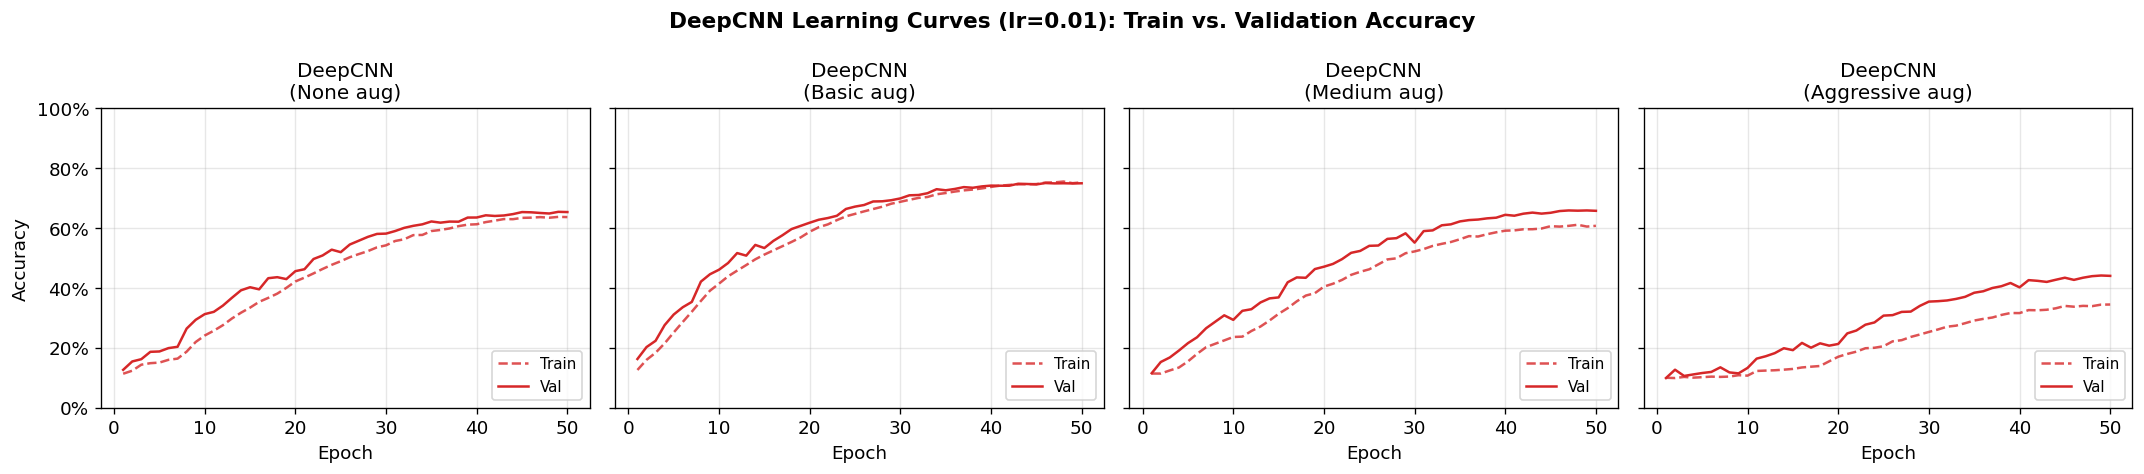

Saved: C:\Users\luluz/cogs181_results_rerun/figures/fig_rerun_learning_curves.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 (Rerun): Learning curves — 1×4 grid, DeepCNN only
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'legend.fontsize':  9,
    'figure.dpi':       120,
})

AUG_LABELS = {'none': 'None', 'basic': 'Basic',
               'medium': 'Medium', 'aggressive': 'Aggressive'}
DEEP_COLOR = '#d62728'

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.suptitle('DeepCNN Learning Curves (lr=0.01): Train vs. Validation Accuracy',
             fontsize=13, fontweight='bold')

for col_i, aug in enumerate(aug_levels):
    ax = axes[col_i]
    hist = all_histories_rerun[('DeepCNN', aug)]
    epochs     = [r['epoch']     for r in hist]
    train_accs = [r['train_acc'] for r in hist]
    val_accs   = [r['val_acc']   for r in hist]

    ax.plot(epochs, train_accs, color=DEEP_COLOR, linewidth=1.5,
            linestyle='--', alpha=0.8, label='Train')
    ax.plot(epochs, val_accs,   color=DEEP_COLOR, linewidth=1.5,
            label='Val')
    ax.set_title(f'DeepCNN\n({AUG_LABELS[aug]} aug)')
    ax.set_ylim(0.0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Epoch')
    if col_i == 0:
        ax.set_ylabel('Accuracy')

plt.tight_layout()
fig.savefig(f'{RERUN_FIGS}/fig_rerun_learning_curves.png', bbox_inches='tight')
plt.show()
print(f'Saved: {RERUN_FIGS}/fig_rerun_learning_curves.png')

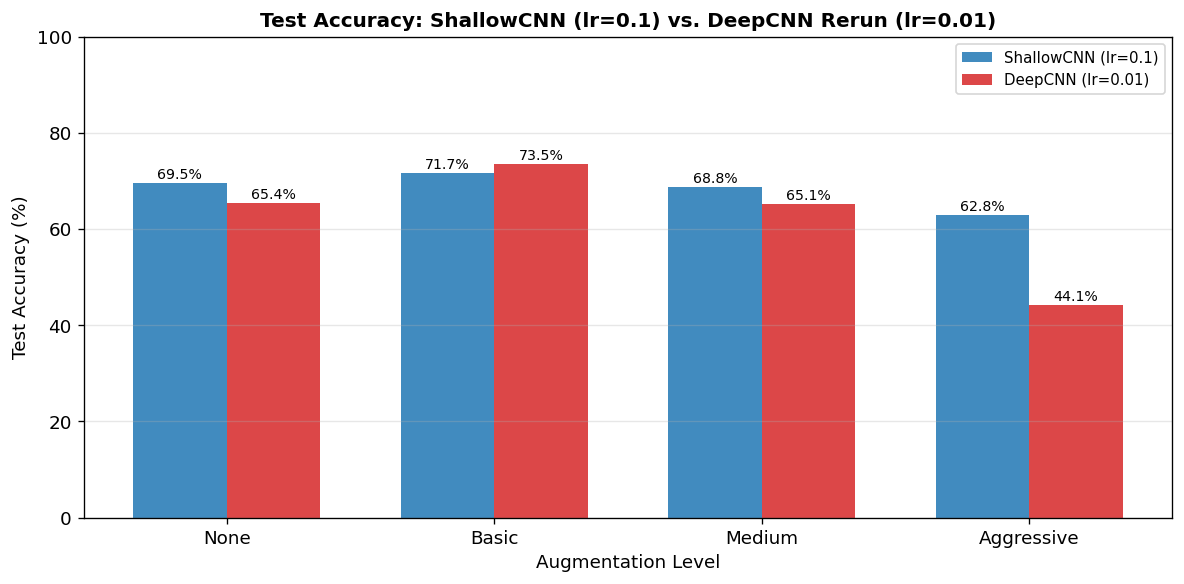

Saved: C:\Users\luluz/cogs181_results_rerun/figures/fig_rerun_comparison.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 (Rerun): Side-by-side comparison bar chart
# ShallowCNN (original lr=0.1) + DeepCNN (rerun lr=0.01)
# ─────────────────────────────────────────────────────────────────────────────
ORIG_RESULTS = os.path.expanduser('~/cogs181_results')

# Load original ShallowCNN results
orig_summary_path = f'{ORIG_RESULTS}/summary.csv'
if os.path.exists(orig_summary_path):
    orig_summary = pd.read_csv(orig_summary_path)
    # summary.csv stores Test Accuracy as formatted string like '69.55%'
    # Convert to float if needed
    if orig_summary['Test Accuracy'].dtype == object:
        orig_summary['test_acc_float'] = orig_summary['Test Accuracy'].str.rstrip('%').astype(float) / 100
    else:
        orig_summary['test_acc_float'] = orig_summary['Test Accuracy']
    shallow_df = orig_summary[orig_summary['Architecture'] == 'ShallowCNN'].copy()
    # Normalize augmentation labels to match our aug_levels keys
    label_to_key = {v: k for k, v in AUG_LABELS.items()}
    shallow_df = shallow_df.copy()
    shallow_df['aug_key'] = shallow_df['Augmentation'].map(label_to_key)
else:
    # Fallback: use hardcoded values from original run
    print(f'WARNING: {orig_summary_path} not found. Using hardcoded original ShallowCNN values.')
    shallow_df = pd.DataFrame({
        'aug_key':       ['none', 'basic', 'medium', 'aggressive'],
        'test_acc_float': [0.6955,  0.7167,  0.6877,  0.6284],
    })

ARCH_COLORS = {'ShallowCNN': '#1f77b4', 'DeepCNN': '#d62728'}

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(aug_levels))
width = 0.35

# ShallowCNN bars (original lr=0.1)
shallow_accs = [
    shallow_df.loc[shallow_df['aug_key'] == aug, 'test_acc_float'].values[0]
    for aug in aug_levels
]
bars_s = ax.bar(x - width/2, [a * 100 for a in shallow_accs], width,
                label='ShallowCNN (lr=0.1)', color=ARCH_COLORS['ShallowCNN'], alpha=0.85)
for bar, acc in zip(bars_s, shallow_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=8.5)

# DeepCNN bars (rerun lr=0.01)
deep_accs = [
    rerun_df.loc[rerun_df['aug'] == aug, 'test_acc'].values[0]
    for aug in aug_levels
]
bars_d = ax.bar(x + width/2, [a * 100 for a in deep_accs], width,
                label='DeepCNN (lr=0.01)', color=ARCH_COLORS['DeepCNN'], alpha=0.85)
for bar, acc in zip(bars_d, deep_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{acc*100:.1f}%',
            ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([AUG_LABELS[a] for a in aug_levels])
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy: ShallowCNN (lr=0.1) vs. DeepCNN Rerun (lr=0.01)',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig(f'{RERUN_FIGS}/fig_rerun_comparison.png', bbox_inches='tight')
plt.show()
print(f'Saved: {RERUN_FIGS}/fig_rerun_comparison.png')

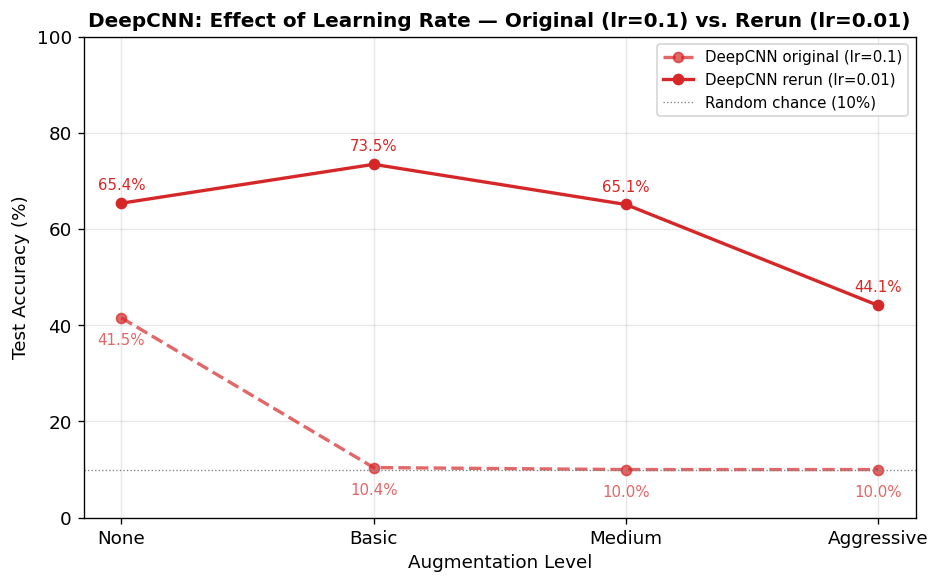

Saved: C:\Users\luluz/cogs181_results_rerun/figures/fig_rerun_lr_comparison.png


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 (Rerun): Original vs. Rerun DeepCNN — effect of LR tuning
# ─────────────────────────────────────────────────────────────────────────────

# Original DeepCNN results (lr=0.1)
original_deep_accs = {
    'none':       0.4153,
    'basic':      0.1042,
    'medium':     0.1000,
    'aggressive': 0.1000,
}

# Rerun DeepCNN results (lr=0.01)
rerun_deep_accs = {
    aug: rerun_df.loc[rerun_df['aug'] == aug, 'test_acc'].values[0]
    for aug in aug_levels
}

aug_x = np.arange(len(aug_levels))

fig, ax = plt.subplots(figsize=(8, 5))

orig_vals  = [original_deep_accs[aug] * 100 for aug in aug_levels]
rerun_vals = [rerun_deep_accs[aug]    * 100 for aug in aug_levels]

ax.plot(aug_x, orig_vals,  marker='o', linewidth=2, linestyle='--',
        color=DEEP_COLOR, alpha=0.7, label='DeepCNN original (lr=0.1)')
ax.plot(aug_x, rerun_vals, marker='o', linewidth=2, linestyle='-',
        color=DEEP_COLOR, label='DeepCNN rerun (lr=0.01)')

# Annotate points
for xi, (ov, rv) in enumerate(zip(orig_vals, rerun_vals)):
    ax.annotate(f'{ov:.1f}%', (xi, ov),
                textcoords='offset points', xytext=(0, -16),
                ha='center', fontsize=9, color=DEEP_COLOR, alpha=0.7)
    ax.annotate(f'{rv:.1f}%', (xi, rv),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color=DEEP_COLOR)

ax.axhline(10, color='gray', linewidth=0.8, linestyle=':', label='Random chance (10%)')
ax.set_xticks(aug_x)
ax.set_xticklabels([AUG_LABELS[a] for a in aug_levels])
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('DeepCNN: Effect of Learning Rate — Original (lr=0.1) vs. Rerun (lr=0.01)',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig(f'{RERUN_FIGS}/fig_rerun_lr_comparison.png', bbox_inches='tight')
plt.show()
print(f'Saved: {RERUN_FIGS}/fig_rerun_lr_comparison.png')